# **Tiền Xử lí dữ liệu**

<a id="toc"></a>
# **MỤC LỤC**
***

**1. <a href='#1'>KHỞI TẠO VÀ TẢI DỮ LIỆU</a>**
> * <a href='#1.1'>1.1. Tải thư viện</a>
> * <a href='#1.2'>1.2. Đọc dữ liệu</a>

**2. <a href='#2'>TỔNG QUAN DỮ LIỆU</a>**
> * <a href='#2.1'>2.1. Kiểu dữ liệu và shape của dữ liệu</a>
> * <a href='#2.2'>2.2. Dữ liệu thiếu, lặp và ngoại lai</a>
> * <a href='#2.2'>2.3. Các giá trị của các thuộc tính 'Object'</a>

**3. <a href='#3'>XỬ LÝ DỮ LIỆU</a>**
> * <a href='#3.1'>3.1. Xử lí object</a>
> * <a href='#3.2'>3.2. Kỹ thuật tạo đặc trưng</a>
> * <a href='#3.3'>3.3. Chia dữ liệu tránh Leakage và Scale dữ liệu</a>
> * <a href='#3.4'>3.4. Xử lí đa cộng tuyến</a>
> * <a href='#3.5'>3.5. Chọn lọc đặc trưng</a>
> * <a href='#3.6'>3.6. Kiểm định K-Fold</a>

**4. <a href='#4'>PHÂN TÍCH TƯƠNG QUAN</a>**


***

***

## <a id='1'>1. Khởi tạo và Tải dữ liệu</a> 


### <a id='1.1'>1.1. Tải thư viện</a> 
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Bước đầu tiên là nhập các thư viện cần thiết cho việc xử lý dữ liệu (Pandas, Numpy) và trực quan hóa cơ bản (Matplotlib, Seaborn). Sau đó, chúng ta sẽ tải bộ dữ liệu `Original.xlsx` vào DataFrame.

In [27]:
#TODO 1: Nhập thư viện và dữ liệu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
import warnings
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
import re
from sklearn.feature_selection import RFE

### <a id='1.2'>1.2. Đọc dữ liệu</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

In [28]:
# TODO 2: Đọc dữ liệu mới và xử lý tên cột
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

# Đọc file dataset mới
file_path = 'Original.xlsx'
df = pd.read_excel(file_path)

# Xử lý tên cột (Dataset mới có nhiều khoảng trắng thừa trong tên cột)
# Xóa khoảng trắng trong tên các cột của dữ liệu.
df.columns = df.columns.str.strip()

# Kiểm tra lại dữ liệu
print("Các cột hiện có:", df.columns.tolist())
df.head()

Các cột hiện có: ['ID', 'Attrition', 'Gender', 'Age', 'Maritalstatus', 'Academic_degree', 'Years_Experience', 'Years_experience_lastorganization', 'Sector', 'Department', 'JobTitle', 'MonthlySalary', 'Allowances', 'MedicalInsurance', 'Bonus', 'OverTime', 'Payment_Overtime', 'Rewards&Wages_Satisfaction', 'Get_ Deserved_Promotion', 'Training_programs_ During_last_three_years', 'Useful_Training_Programs', 'Business_Travel', 'Job_Support', 'Recognition', 'Emotional_Commitment', 'Job_Engagement', 'Distance_to_work', 'Work_Live_Balance', 'Physical_Stress', 'Psychological_Exhaustion', 'Job_Stability', 'Health_Issues', 'Environment_Satisfaction', 'Job_Satisfaction', 'Job_Opportunities']


,ID,Attrition,Gender,Age,Maritalstatus,Academic_degree,Years_Experience,Years_experience_lastorganization,Sector,Department,JobTitle,MonthlySalary,Allowances,MedicalInsurance,Bonus,OverTime,Payment_Overtime,Rewards&Wages_Satisfaction,Get_ Deserved_Promotion,Training_programs_ During_last_three_years,Useful_Training_Programs,Business_Travel,Job_Support,Recognition,Emotional_Commitment,Job_Engagement,Distance_to_work,Work_Live_Balance,Physical_Stress,Psychological_Exhaustion,Job_Stability,Health_Issues,Environment_Satisfaction,Job_Satisfaction,Job_Opportunities
0,11,Yes,Female,31 to 40,Married,Master's,Less than 5 years,Less than 5 years,Medical sector,Accounting,Accountant,From 5000 to 10000 S.R,2,No,No,No,I don't have overtime,Yes,Yes,From 1 to 3 training programs,Yes,I do not travel for work,Medium,No,Medium,Medium,Medium,Medium,Yes,No,No,Yes,Medium,Not satisfied,Yes
1,12,No,Female,21 to 30,Single,Master's,Less than 5 years,Less than 5 years,Medical sector,Accounting,Accountant,From 11000 to 15000 S.R,2,Yes,Yes,No,I don't have overtime,Yes,Yes,From 1 to 3 training programs,Yes,Travel rarely,Medium,Yes,Medium,Medium,Medium,Medium,No,No,Yes,No,Medium,Satisfied,No
2,13,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,Teacher,Less than 5000 SAR,0,No,No,No,I don't have overtime,No,No,From 1 to 3 training programs,Yes,I do not travel for work,Medium,Yes,Low,Medium,Close,Medium,Yes,Sometimes,No,No,Medium,Satisfied,Yes
3,14,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,Teacher,Less than 5000 SAR,0,No,No,No,I don't have overtime,No,No,I did not receive any training,No,I do not travel for work,Low,No,Low,Medium,Medium,Medium,Yes,Yes,No,No,Low,Not satisfied,No
4,15,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,Teacher,Less than 5000 SAR,0,No,No,Yes,No,No,No,I did not receive any training,No,I do not travel for work,Low,Yes,Medium,Medium,Medium,Medium,Sometimes,Sometimes,No,No,Medium,Not satisfied,No


## <a id='2'>2. Tổng quan dữ liệu</a>


### <a id='2.1'>2.1. Kiểu dữ liệu và shape của dữ liệu</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Trước khi xử lý, ta cần nắm bắt kích thước dữ liệu, kiểu dữ liệu của từng thuộc tính và kiểm tra sơ bộ các giá trị thống kê. Điều này giúp xác định xem dữ liệu có chứa giá trị null hay không và định dạng đã chuẩn chưa.

In [29]:
#TODO 3: Tổng quan dữ liệu 
# Kiểm tra kích thước dữ liệu (số dòng, số cột)
print(f"Kích thước dataset: {df.shape}")

# Kiểm tra thông tin kiểu dữ liệu và giá trị thiếu (null)
df.info()

# Thống kê mô tả cho các biến định lượng
df.describe()

Kích thước dataset: (1191, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1191 entries, 0 to 1190
Data columns (total 35 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   ID                                          1191 non-null   int64 
 1   Attrition                                   1191 non-null   object
 2   Gender                                      1191 non-null   object
 3   Age                                         1191 non-null   object
 4   Maritalstatus                               1191 non-null   object
 5   Academic_degree                             1191 non-null   object
 6   Years_Experience                            1191 non-null   object
 7   Years_experience_lastorganization           1191 non-null   object
 8   Sector                                      1191 non-null   object
 9   Department                                  1191 non-null   objec

,ID,Allowances
count,1191.000000,1191.000000
mean,612.910999,1.222502
std,346.732295,1.187483
min,11.000000,0.000000
25%,314.500000,0.000000
50%,613.000000,1.000000
75%,912.500000,2.000000
max,1213.000000,4.000000


### <a id='2.2'>2.2. Dữ liệu thiếu, lặp và Ngoại lai</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

In [30]:
df = df.drop('ID', axis=1)

missing_values = df.isnull().sum()
print("Các cột có giá trị thiếu:",missing_values[missing_values > 0])

print(f"Số dòng trùng lặp: {df.duplicated().sum()}")

Các cột có giá trị thiếu: Series([], dtype: int64)
Số dòng trùng lặp: 1


**Tìm Ngoại lai:** Do chỉ có Allowances là kiểu int nên cần xem xét.

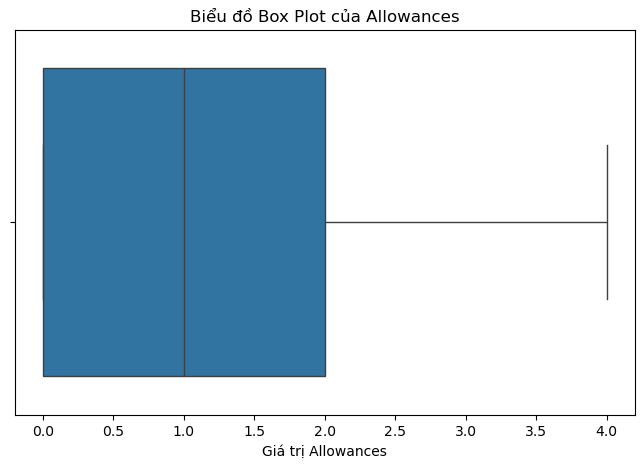

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Allowances'])
plt.title('Biểu đồ Box Plot của Allowances')
plt.xlabel('Giá trị Allowances')
plt.show()

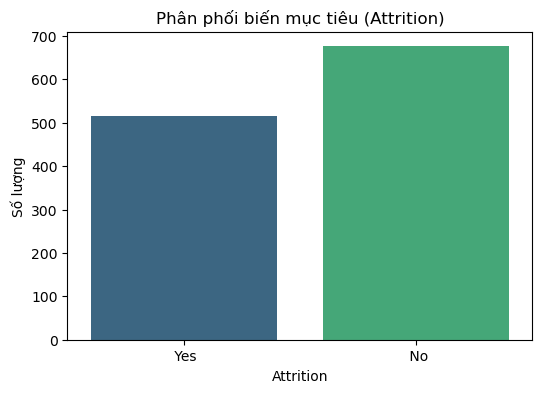

Attrition
No     56.759026
Yes    43.240974
Name: proportion, dtype: float64


In [32]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', palette='viridis')
plt.title('Phân phối biến mục tiêu (Attrition)')
plt.ylabel('Số lượng')
plt.show()

# Xem tỷ lệ phần trăm
print(df['Attrition'].value_counts(normalize=True) * 100)

### <a id='2.3'>2.3. Các giá trị của các thuộc tính 'Object'</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Trước khi xử lý dữ liệu, chúng ta cần xem xét các giá trị thực tế chứa trong các cột dạng chuỗi (Object). Bước này giúp phát hiện:
* Các định dạng không nhất quán (ví dụ: "Male" và "male").
* Các ký tự lạ hoặc khoảng trắng thừa.
* Cấu trúc của các biến dạng khoảng (ví dụ: Age là "30-40" hay "30 to 40").

In [33]:
# Lọc ra các cột có kiểu dữ liệu là object
object_cols = df.select_dtypes(include=['object']).columns

print(f"Tìm thấy {len(object_cols)} cột dạng Object.\n")

for col in object_cols:
    print(f"--- Cột: {col} ---")
    unique_values = df[col].unique()
    
    # In ra số lượng giá trị duy nhất
    print(f"Số lượng giá trị (Cardinallity): {len(unique_values)}")
    
    # In ra danh sách các giá trị để kiểm tra
    # Nếu danh sách quá dài (>50) thì chỉ in 50 giá trị đầu để tránh spam màn hình
    if len(unique_values) > 50:
        print(f"Giá trị (50 mẫu đầu tiên): {unique_values[:50]}")
        print("... (Danh sách quá dài, đã bị cắt bớt)")
    else:
        print(f"Giá trị: {unique_values}")
    
    print("\n" + "="*50 + "\n")

Tìm thấy 33 cột dạng Object.

--- Cột: Attrition ---
Số lượng giá trị (Cardinallity): 2
Giá trị: [' Yes' ' No']


--- Cột: Gender ---
Số lượng giá trị (Cardinallity): 2
Giá trị: ['Female' ' Male']


--- Cột: Age ---
Số lượng giá trị (Cardinallity): 4
Giá trị: ['31 to 40' '21 to 30 ' '41 to 50' '51 to 60 ']


--- Cột: Maritalstatus ---
Số lượng giá trị (Cardinallity): 4
Giá trị: [' Married' ' Single' 'Married' ' Divorced']


--- Cột: Academic_degree ---
Số lượng giá trị (Cardinallity): 5
Giá trị: [" Master's" " Bachelor's" 'Diploma or secondary' 'Ph.D' "Bachelor's"]


--- Cột: Years_Experience ---
Số lượng giá trị (Cardinallity): 10
Giá trị: [' Less than 5 years' 'Less than 5 years' 'From 5 to 10 years'
 '\xa0From 5 to 10 years' 'From 11 to 15 years' 'From 16 to 20 years'
 'From 21 to 25 years' 'From 31 to 35 years' '\xa0From 11 to 15 years'
 'From 26 to 30 years']


--- Cột: Years_experience_lastorganization ---
Số lượng giá trị (Cardinallity): 7
Giá trị: [' Less than 5 years' 'From 5 

In [34]:
# Lọc lấy các cột Object
obj_df = df.select_dtypes(include=['object'])

# Tính số lượng giá trị duy nhất (unique) cho từng cột
unique_counts = obj_df.nunique()

# Phân loại
# Cột có > 2 giá trị (Cần Ordinal Encoding hoặc One-Hot Encoding/Get Dummies)
multi_value_cols = unique_counts[unique_counts > 2]

# Cột có <= 2 giá trị (Thường là Binary: Yes/No -> Map 1/0)
binary_cols = unique_counts[unique_counts <= 2]

print(f"--- CÁC CỘT CÓ > 2 GIÁ TRỊ ({len(multi_value_cols)} cột) ---")
display(multi_value_cols)

print(f"\n--- CÁC CỘT CÓ <= 2 GIÁ TRỊ ({len(binary_cols)} cột) ---")
display(binary_cols)


--- CÁC CỘT CÓ > 2 GIÁ TRỊ (21 cột) ---


Age                                            4
Maritalstatus                                  4
Academic_degree                                5
Years_Experience                              10
Years_experience_lastorganization              7
Sector                                        16
Department                                    26
JobTitle                                      81
MonthlySalary                                  7
Payment_Overtime                               3
Training_programs_ During_last_three_years     4
Business_Travel                                3
Job_Support                                    3
Emotional_Commitment                           3
Job_Engagement                                 3
Distance_to_work                               3
Work_Live_Balance                              3
Physical_Stress                                3
Psychological_Exhaustion                       3
Environment_Satisfaction                       3
Job_Satisfaction    


--- CÁC CỘT CÓ <= 2 GIÁ TRỊ (12 cột) ---


Attrition                     2
Gender                        2
MedicalInsurance              2
Bonus                         2
OverTime                      2
Rewards&Wages_Satisfaction    2
Get_ Deserved_Promotion       2
Useful_Training_Programs      2
Recognition                   2
Job_Stability                 2
Health_Issues                 2
Job_Opportunities             2
dtype: int64

## <a id='3'>3. Xử lí dữ liệu</a>


Việc chủ yếu cần làm
1. Do dữ liệu không có các giá trị lặp hoặc dữ liệu bị thiếu (NaN). Nên không cần làm sạch.
2. Xử lí các cột object nhưng có ý nghĩa về số lượng thay vì định danh bằng cách sử dụng thư viện `re`
3. xử lí các cột bị "SPACE" ở rìa các giá trị của các thuộc tính, có thể khiến cho việc thay đổi kiểu dữ liệu bị lỗi. VD: thay vì tuổi cụ thể, thì lại là `Missing Value` do còn vướng "SPACE"

### <a id='3.1'>3.1. Xử lí object</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Quy trình xử lý:
1.  **Global Stripping:** Loại bỏ khoảng trắng thừa cho toàn bộ cột Object.
2.  **Mapping biến mục tiêu:** Chuyển `Attrition` (Yes/No) thành (1/0).
3.  **Text Processing (Nâng cao):**
    * "Do not" / "Did not" $\rightarrow$ 0.
    * "Less than X" $\rightarrow$ $X / 2$ (Ước lượng trung bình khoảng từ 0 đến X).
    * "X to Y" $\rightarrow$ $(X + Y) / 2$ (Trung bình cộng).

In [35]:
def Stripping(df):
    """
    Hàm tự động lọc tất cả các cột kiểu Object trong DataFrame
    và loại bỏ khoảng trắng thừa (strip).
    """
    # Lấy danh sách các cột là object (chữ)
    obj_cols = df.select_dtypes(include=['object']).columns
    
    print(f"--- Đang thực hiện Strip cho {len(obj_cols)} cột object ---")
    for col in obj_cols:
        df[col] = df[col].str.strip()
    return df

def process_text_range(text):
    if pd.isna(text):
        return np.nan
    
    # Chuyển về chữ thường
    text_str = str(text).lower()
    
    # Xử lý trường hợp không có/không làm (trả về 0)
    if 'do not' in text_str or 'did not' in text_str:
        return 0.0
    
    # Tìm tất cả các số trong chuỗi
    numbers = re.findall(r'\d+', text_str)
    if not numbers:
        return np.nan
        
    # Chuyển list string sang list float
    numbers = [float(n) for n in numbers]
    
    
    # Các trường hợp còn lại (Range: "30 to 40") -> Lấy trung bình
    return np.mean(numbers)


In [36]:
df = Stripping(df)

--- Đang thực hiện Strip cho 33 cột object ---


In [37]:
# Danh sách các cột cần xử lý
object_cols_to_convert = [
    'Age', 
    'MonthlySalary', 
    'Years_Experience', 
    'Years_experience_lastorganization',
    'Training_programs_ During_last_three_years'
]

print("Dữ liệu trước khi xử lý:")
display(df[object_cols_to_convert].head(10))

# Áp dụng hàm xử lý
for col in object_cols_to_convert:
    df[col] = df[col].apply(process_text_range)

print("-" * 30)
print("Dữ liệu sau khi xử lý (đã chuyển về dạng số):")
display(df[object_cols_to_convert].head(10))

# Kiểm tra lại kiểu dữ liệu
print(df[object_cols_to_convert].dtypes)

Dữ liệu trước khi xử lý:


,Age,MonthlySalary,Years_Experience,Years_experience_lastorganization,Training_programs_ During_last_three_years
0,31 to 40,From 5000 to 10000 S.R,Less than 5 years,Less than 5 years,From 1 to 3 training programs
1,21 to 30,From 11000 to 15000 S.R,Less than 5 years,Less than 5 years,From 1 to 3 training programs
2,21 to 30,Less than 5000 SAR,Less than 5 years,Less than 5 years,From 1 to 3 training programs
3,21 to 30,Less than 5000 SAR,Less than 5 years,Less than 5 years,I did not receive any training
4,21 to 30,Less than 5000 SAR,Less than 5 years,Less than 5 years,I did not receive any training
5,21 to 30,Less than 5000 SAR,Less than 5 years,Less than 5 years,From 4 to 6 training programs
6,31 to 40,Less than 5000 SAR,Less than 5 years,Less than 5 years,From 1 to 3 training programs
7,31 to 40,From 11000 to 15000 S.R,From 5 to 10 years,From 5 to 10 years,From 7 training programs to more
8,31 to 40,Less than 5000 SAR,From 5 to 10 years,Less than 5 years,From 1 to 3 training programs
9,21 to 30,Less than 5000 SAR,Less than 5 years,Less than 5 years,From 1 to 3 training programs


------------------------------
Dữ liệu sau khi xử lý (đã chuyển về dạng số):


,Age,MonthlySalary,Years_Experience,Years_experience_lastorganization,Training_programs_ During_last_three_years
0,35.5,7500.0,5.0,5.0,2.0
1,25.5,13000.0,5.0,5.0,2.0
2,25.5,5000.0,5.0,5.0,2.0
3,25.5,5000.0,5.0,5.0,0.0
4,25.5,5000.0,5.0,5.0,0.0
5,25.5,5000.0,5.0,5.0,5.0
6,35.5,5000.0,5.0,5.0,2.0
7,35.5,13000.0,7.5,7.5,7.0
8,35.5,5000.0,7.5,5.0,2.0
9,25.5,5000.0,5.0,5.0,2.0


Age                                           float64
MonthlySalary                                 float64
Years_Experience                              float64
Years_experience_lastorganization             float64
Training_programs_ During_last_three_years    float64
dtype: object


Ngoài ra, chúng ta cũng cần chuẩn hóa các biến định danh (Categorical) nhị phân đơn giản (Yes/No) về dạng số (1/0) để thuận tiện cho mô hình học máy sau này.

Trước tiên cần phải xóa các dấu "SPACE" trước khi chuyển đổi dữ liệu `Attrition`.

In [38]:
# 
# Cột Payment_Overtime có giá trị "I don't have overtime", coi là No (0)
binary_mapping = {'Yes': 1, 'No': 0}

# Các cột Yes/No thuần túy
binary_cols = [
    'Attrition', 'MedicalInsurance', 'Bonus', 'OverTime', 
    'Rewards&Wages_Satisfaction', 'Get_ Deserved_Promotion', 
    'Useful_Training_Programs', 'Recognition', 'Job_Stability', 
    'Health_Issues', 'Job_Opportunities'
]
for col in binary_cols:
    df[col] = df[col].map(binary_mapping)


# Dictionary map thủ công cho các biến có thứ tự 
ordinal_maps = {
    'Job_Satisfaction': {'Not satisfied': 0, 'Satisfied': 1, 'Very satisfied': 2},
    'Job_Support': {'Low': 0, 'Medium': 1, 'High': 2},
    'Business_Travel': {'I do not travel for work': 0, 'Travel rarely': 1, 'Travel frequently': 2},
    'Academic_degree': {'Diploma or secondary': 0, "Bachelor's": 1, "Master's": 2, 'Ph.D': 3},
    'Work_Live_Balance': {'Difficult': 2, 'Medium': 1, 'Easy': 0},
    'Job_Engagement': {'Difficult': 2, 'Medium': 1, 'Easy': 0},
    'Environment_Satisfaction': { 'Low': 0,'Medium': 1,'High': 2 },
    'Emotional_Commitment':{ 'Low': 0,'Medium': 1,'High': 2 },
    'Distance_to_work': {'Close': 0, 'Medium':1,'Far':2},
    'Physical_Stress':{'No':0,'Sometimes':1,'Yes':2},
    'Psychological_Exhaustion':{'No':0,'Sometimes':1,'Yes':2}
}

# Áp dụng map
for col, mapper in ordinal_maps.items():
    if col in df.columns:
        df[col] = df[col].map(mapper)

# Xử lý JobTitle bằng Frequency Encoding (Tránh tạo 71 cột mới)
# Thay mỗi JobTitle bằng tỷ lệ phần trăm xuất hiện của nó

job_freq = df['JobTitle'].value_counts(normalize=True)
df['JobTitle_Freq'] = df['JobTitle'].map(job_freq)
# Xóa cột JobTitle gốc (hoặc giữ lại nếu muốn so sánh)
df.drop('JobTitle', axis=1, inplace=True) 


# One-Hot Encoding cho các biến định danh còn lại (Gender, Sector...)
# Chỉ làm One-Hot cho các cột ít giá trị
nominal_cols = ['Maritalstatus', 'Sector', 'Department'] 
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Tạo biến tổng hợp (Feature Engineering)
# Ví dụ: Tổng điểm hài lòng
df['Total_Satisfaction'] = df['Job_Satisfaction'] + df['Job_Support'] + df['Environment_Satisfaction']

print("Dữ liệu sau khi nâng cấp xử lý đặc trưng:")
print(df.info())



# Xử lý riêng cột Payment_Overtime
df['Payment_Overtime'] = df['Payment_Overtime'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Gender'] = df['Gender'].replace({'Female' : 0, 'Male':1})
print("Đã mã hóa xong các biến nhị phân.")

Dữ liệu sau khi nâng cấp xử lý đặc trưng:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1191 entries, 0 to 1190
Data columns (total 71 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Attrition                                          1191 non-null   int64  
 1   Gender                                             1191 non-null   object 
 2   Age                                                1191 non-null   float64
 3   Academic_degree                                    1191 non-null   int64  
 4   Years_Experience                                   1191 non-null   float64
 5   Years_experience_lastorganization                  1191 non-null   float64
 6   MonthlySalary                                      1191 non-null   float64
 7   Allowances                                         1191 non-null   int64  
 8   MedicalInsurance                              

### <a id='3.2'>3.2. Kỹ thuật tạo đặc trưng</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

In [39]:


# Chỉ số Áp lực (Pressure Score)
# Tổng hợp từ Stress thể chất, kiệt sức tinh thần và làm thêm giờ
# Càng cao càng dễ nghỉ việc
df['Pressure_Score'] = (df['Physical_Stress'] + 
                        df['Psychological_Exhaustion'] + 
                        df['OverTime'] + 
                        df['Payment_Overtime'])

# Chỉ số Gắn kết tổng thể (Overall Engagement Score)
# Tổng hợp các biến tích cực về môi trường và công việc
df['Overall_Engagement'] = (df['Job_Satisfaction'] + 
                            df['Job_Support'] + 
                            df['Environment_Satisfaction'] + 
                            df['Emotional_Commitment'] + 
                            df['Job_Engagement'])

# Chỉ số "Nhảy việc" (Stability Ratio)
# Tỷ lệ: Kinh nghiệm tại tổ chức cũ / Tổng số năm kinh nghiệm
# Ý nghĩa: Nếu tỷ lệ này thấp (tức là làm ở chỗ cũ rất ngắn so với tổng đời làm việc), 
# người này có xu hướng nhảy việc nhiều.
# Cộng thêm 0.1 để tránh lỗi chia cho 0
df['Stability_Ratio'] = df['Years_experience_lastorganization'] / (df['Years_Experience'] + 0.1)

# Tốc độ thăng tiến (Career Velocity)
# Mức lương / Số năm kinh nghiệm
# Ý nghĩa: Lương cao nhưng ít kinh nghiệm -> Tài năng/Được trọng dụng -> Khó nghỉ việc hơn (hoặc dễ bị săn đón?)
df['Career_Velocity'] = df['MonthlySalary'] / (df['Years_Experience'] + 1)

# Chỉ số Đào tạo hiệu quả (Effective Training)
# Số lượng chương trình * Tính hữu ích (Useful=1, No=0)
# Ý nghĩa: Đi học nhiều mà thấy không hữu ích thì cũng bằng thừa.
df['Effective_Training_Score'] = df['Training_programs_ During_last_three_years'] * df['Useful_Training_Programs']

# Chỉ số Mất cân bằng (Imbalance Score)
# Khoảng cách xa + Cân bằng cuộc sống khó khăn (đã map Difficult=2)
df['Life_Work_Imbalance'] = df['Distance_to_work'] + df['Work_Live_Balance']

print("Các cột đặc trưng mới đã được tạo:")
new_features = ['Pressure_Score', 'Overall_Engagement', 'Stability_Ratio', 'Career_Velocity', 'Effective_Training_Score', 'Life_Work_Imbalance']
display(df[new_features].head())
display(df[new_features].describe())
display(df.head(20))

df.to_csv('Clean_Data_for_EDA.csv', index=False)

Các cột đặc trưng mới đã được tạo:


,Pressure_Score,Overall_Engagement,Stability_Ratio,Career_Velocity,Effective_Training_Score,Life_Work_Imbalance
0,2,4,0.980392,1250.000000,2.0,2
1,0,5,0.980392,2166.666667,2.0,2
2,3,4,0.980392,833.333333,2.0,1
3,4,1,0.980392,833.333333,0.0,2
4,3,3,0.980392,833.333333,0.0,2


,Pressure_Score,Overall_Engagement,Stability_Ratio,Career_Velocity,Effective_Training_Score,Life_Work_Imbalance
count,1191.000000,1191.000000,1191.000000,1191.000000,1191.000000,1191.000000
mean,2.833753,5.234257,0.900251,963.972944,2.342569,1.821159
std,1.652369,2.125010,0.174076,485.856987,2.494402,1.043148
min,0.000000,0.000000,0.216450,172.413793,0.000000,0.000000
25%,2.000000,4.000000,0.980392,833.333333,0.000000,1.000000
50%,3.000000,5.000000,0.980392,882.352941,2.000000,2.000000
75%,4.000000,7.000000,0.986842,1250.000000,5.000000,2.000000
max,6.000000,10.000000,0.996979,5166.666667,7.000000,4.000000


,Attrition,Gender,Age,Academic_degree,Years_Experience,Years_experience_lastorganization,MonthlySalary,Allowances,MedicalInsurance,Bonus,OverTime,Payment_Overtime,Rewards&Wages_Satisfaction,Get_ Deserved_Promotion,Training_programs_ During_last_three_years,Useful_Training_Programs,Business_Travel,Job_Support,Recognition,Emotional_Commitment,Job_Engagement,Distance_to_work,Work_Live_Balance,Physical_Stress,Psychological_Exhaustion,Job_Stability,Health_Issues,Environment_Satisfaction,Job_Satisfaction,Job_Opportunities,JobTitle_Freq,Maritalstatus_Married,Maritalstatus_Single,Sector_Economic sector,Sector_Education sector,Sector_Energy sector,Sector_Engineering consulting companies,"Sector_Environment, Water, and Agriculture sector",Sector_Financial sector,Sector_Food production sector,Sector_Industry sector,Sector_Law firm,Sector_Media sector,Sector_Medical sector,Sector_Restaurant sector,Sector_Tourism sector,Sector_Transport sector,Sector_education sector,Department_Administration,Department_Banking operations,Department_Customers service,Department_Engineering,Department_HR,Department_Information technology,Department_Legal Affairs,Department_Marketing,Department_Medical service,Department_Patient Affairs,Department_Processes,Department_Production,Department_Relations,Department_Safety & Security,Department_Sales,Department_Studies and design,Department_Teaching,Department_Technical support,Department_Training,Department_Treasury,Department_patient Affairs,Department_technical support,Total_Satisfaction,Pressure_Score,Overall_Engagement,Stability_Ratio,Career_Velocity,Effective_Training_Score,Life_Work_Imbalance
0,1,0,35.5,2,5.0,5.0,7500.0,2,0,0,0,0,1,1,2.0,1,0,1,0,1,1,1,1,2,0,0,1,1,0,1,0.036104,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2,2,4,0.980392,1250.000000,2.0,2
1,0,0,25.5,2,5.0,5.0,13000.0,2,1,1,0,0,1,1,2.0,1,1,1,1,1,1,1,1,0,0,1,0,1,1,0,0.036104,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,3,0,5,0.980392,2166.666667,2.0,2
2,0,0,25.5,1,5.0,5.0,5000.0,0,0,0,0,0,0,0,2.0,1,0,1,1,0,1,0,1,2,1,0,0,1,1,1,0.138539,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,3,3,4,0.980392,833.333333,2.0,1
3,0,0,25.5,1,5.0,5.0,5000.0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,1,1,1,2,2,0,0,0,0,0,0.138539,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,0,4,1,0.980392,833.333333,0.0,2
4,0,0,25.5,1,5.0,5.0,5000.0,0,0,0,1,0,0,0,0.0,0,0,0,1,1,1,1,1,1,1,0,0,1,0,0,0.138539,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,1,3,3,0.980392,833.333333,0.0,2
5,0,0,25.5,1,5.0,5.0,5000.0,0,0,0,0,0,0,0,5.0,1,0,0,0,1,1,0,1,2,2,0,0,0,0,1,0.138539,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,0,4,2,0.980392,833.333333,5.0,1
6,1,0,35.5,1,5.0,5.0,5000.0,0,0,0,1,0,0,0,2.0,1,0,1,1,1,1,0,2,2,2,0,0,1,1,0,0.138539,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fals

### <a id='3.3'>3.3. Chia dữ liệu tránh Leakage và Scale dữ liệu</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

In [40]:

# Kiểm tra và xử lý lỗi phát sinh từ bước Feature Engineering
# Phép chia có thể tạo ra Infinity (vô cực) hoặc NaN. Ta thay thế bằng 0.
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.fillna(0)

# Tách biến độc lập (X) và biến mục tiêu (y)
target = 'Attrition'
if target in df.columns:
    X = df.drop(target, axis=1)
    y = df[target]
else:
    print("Lỗi: Không tìm thấy cột Attrition. Kiểm tra lại tên cột.")

# Chia tập Train (Huấn luyện) và Test (Kiểm tra)
# Tỷ lệ 80% Train - 20% Test. Stratify=y để đảm bảo tỷ lệ nghỉ việc ở 2 tập đều nhau.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

# Chuẩn hóa dữ liệu (Scaling)
# Chọn MinMaxScaler (đưa về 0-1) vì dữ liệu của bạn có nhiều biến dạng điểm số/xếp hạng
scaler = MinMaxScaler()

# Chỉ fit (học) trên X_train, sau đó transform (áp dụng) cho cả Train và Test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Chuyển lại thành DataFrame để giữ tên cột (giúp dễ đọc hơn là để dạng numpy array)
X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

print("-" * 30)
print("Dữ liệu sau khi chuẩn hóa (5 dòng đầu của X_train):")
display(X_train.head())

Kích thước tập Train: (952, 76)
Kích thước tập Test: (239, 76)
------------------------------
Dữ liệu sau khi chuẩn hóa (5 dòng đầu của X_train):


,Gender,Age,Academic_degree,Years_Experience,Years_experience_lastorganization,MonthlySalary,Allowances,MedicalInsurance,Bonus,OverTime,Payment_Overtime,Rewards&Wages_Satisfaction,Get_ Deserved_Promotion,Training_programs_ During_last_three_years,Useful_Training_Programs,Business_Travel,Job_Support,Recognition,Emotional_Commitment,Job_Engagement,Distance_to_work,Work_Live_Balance,Physical_Stress,Psychological_Exhaustion,Job_Stability,Health_Issues,Environment_Satisfaction,Job_Satisfaction,Job_Opportunities,JobTitle_Freq,Maritalstatus_Married,Maritalstatus_Single,Sector_Economic sector,Sector_Education sector,Sector_Energy sector,Sector_Engineering consulting companies,"Sector_Environment, Water, and Agriculture sector",Sector_Financial sector,Sector_Food production sector,Sector_Industry sector,Sector_Law firm,Sector_Media sector,Sector_Medical sector,Sector_Restaurant sector,Sector_Tourism sector,Sector_Transport sector,Sector_education sector,Department_Administration,Department_Banking operations,Department_Customers service,Department_Engineering,Department_HR,Department_Information technology,Department_Legal Affairs,Department_Marketing,Department_Medical service,Department_Patient Affairs,Department_Processes,Department_Production,Department_Relations,Department_Safety & Security,Department_Sales,Department_Studies and design,Department_Teaching,Department_Technical support,Department_Training,Department_Treasury,Department_patient Affairs,Department_technical support,Total_Satisfaction,Pressure_Score,Overall_Engagement,Stability_Ratio,Career_Velocity,Effective_Training_Score,Life_Work_Imbalance
0,1.0,0.333333,0.333333,0.089286,0.000000,0.307692,0.5,1.0,1.0,0.0,0.0,1.0,1.0,0.285714,1.0,0.0,1.0,0.0,0.0,0.5,0.0,1.0,1.0,0.5,0.0,1.0,0.5,0.5,1.0,0.097561,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.500000,0.5,0.565571,0.271712,0.285714,0.50
1,1.0,0.000000,0.333333,0.089286,0.089286,0.000000,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.714286,1.0,0.5,1.0,1.0,0.5,0.5,0.5,0.5,0.0,0.0,0.0,1.0,0.5,0.5,1.0,0.048780,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.000000,0.6,0.987013,0.083260,0.714286,0.50
2,0.0,0.000000,0.333333,0.000000,0.000000,0.096154,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.5,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.317073,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.666667,0.1,0.978749,0.215765,0.000000,0.50
3,1.0,0.333333,0.000000,0.089286,0.089286,0.307692,0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.5,0.5,1.0,0.0,0.0,1.0,0.0,1.0,0.243902,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.500000,0.4,0.987013,0.271712,0.000000,0.25
4,1.0,0.000000,0.333333,0.000000,0.000000,0.096154,0.5,1.0,1.0,1.0,1.0,0.0,0.0,0.285714,1.0,0.0,0.0,0.0,1.0,1.0,0.5,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.042683,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.4,0.978749,0.215765,0.285714,0.75


### <a id='3.4'>3.4. Loại bỏ các đặc trưng bị đa cộng tuyến</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

BẢNG PHÂN TÍCH TÁC ĐỘNG CỦA NGƯỠNG LOẠI BỎ:
------------------------------------------------------------
Ngưỡng (Threshold)   | Số cột bị loại  | Ví dụ cột bị loại
------------------------------------------------------------
0.7                  | 10              | ['Years_experience_lastorganization', 'Maritalstatus_Single', 'Department_Legal Affairs']...
0.75                 | 9               | ['Years_experience_lastorganization', 'Maritalstatus_Single', 'Department_Legal Affairs']...
0.8                  | 7               | ['Years_experience_lastorganization', 'Maritalstatus_Single', 'Department_Legal Affairs']...
0.85                 | 4               | ['Maritalstatus_Single', 'Department_Legal Affairs', 'Overall_Engagement']...
0.9                  | 4               | ['Maritalstatus_Single', 'Department_Legal Affairs', 'Overall_Engagement']...
0.95                 | 2               | ['Maritalstatus_Single', 'Department_Legal Affairs']...


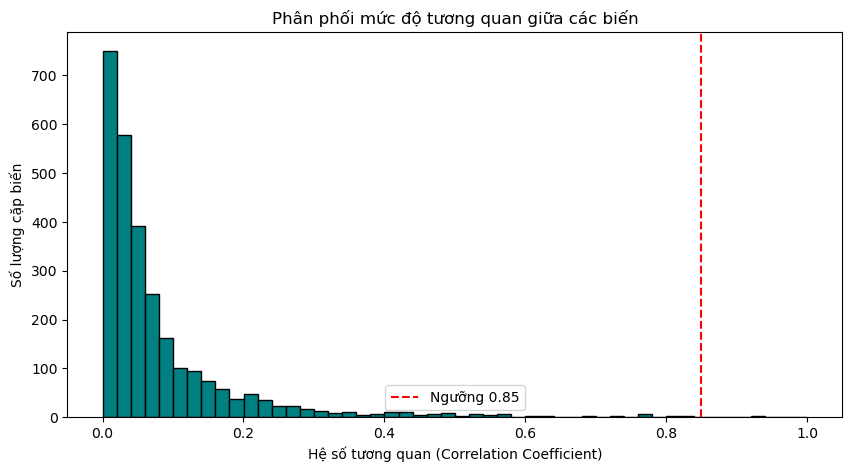

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tính ma trận tương quan tuyệt đối
corr_matrix = X_train.corr().abs()

# Chỉ lấy phần tam giác trên (tránh trùng lặp)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Thử nghiệm các ngưỡng khác nhau
thresholds = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
print("BẢNG PHÂN TÍCH TÁC ĐỘNG CỦA NGƯỠNG LOẠI BỎ:")
print("-" * 60)
print(f"{'Ngưỡng (Threshold)':<20} | {'Số cột bị loại':<15} | {'Ví dụ cột bị loại'}")
print("-" * 60)

for thresh in thresholds:
    to_drop = [column for column in upper.columns if any(upper[column] > thresh)]
    print(f"{thresh:<20} | {len(to_drop):<15} | {to_drop[:3]}...") # Chỉ in 3 cột ví dụ

# Vẽ biểu đồ phân phối các giá trị tương quan
# Giúp bạn nhìn xem đa số các cột tương quan ở mức nào
all_correlations = upper.stack().values
plt.figure(figsize=(10, 5))
plt.hist(all_correlations, bins=50, color='teal', edgecolor='black')
plt.axvline(x=0.85, color='red', linestyle='--', label='Ngưỡng 0.85')
plt.title('Phân phối mức độ tương quan giữa các biến')
plt.xlabel('Hệ số tương quan (Correlation Coefficient)')
plt.ylabel('Số lượng cặp biến')
plt.legend()
plt.show()

In [42]:
# Tính ma trận tương quan (Lấy trị tuyệt đối)
corr_matrix = X_train.corr().abs()

# Chọn phần tam giác trên của ma trận (để không kiểm tra trùng lặp)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Tìm các cột có độ tương quan > 0.85 (Ngưỡng an toàn)
to_drop = [column for column in upper.columns if any(upper[column] > 0.7)]

print(f"Phát hiện {len(to_drop)} cột bị đa cộng tuyến cao (>0.7):")
print(to_drop)

# Xóa các cột này khỏi Train và Test
X_train_filtered = X_train.drop(columns=to_drop)
X_test_filtered = X_test.drop(columns=to_drop)

print(f"Số lượng cột còn lại sau khi lọc tương quan: {X_train_filtered.shape[1]}")

Phát hiện 10 cột bị đa cộng tuyến cao (>0.7):
['Years_experience_lastorganization', 'Maritalstatus_Single', 'Department_Legal Affairs', 'Department_Teaching', 'Total_Satisfaction', 'Pressure_Score', 'Overall_Engagement', 'Career_Velocity', 'Effective_Training_Score', 'Life_Work_Imbalance']
Số lượng cột còn lại sau khi lọc tương quan: 66


### <a id='3.5'>3.5. Chọn lọc đặc trưng</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Top 20 đặc trưng được chọn:
['Age', 'Academic_degree', 'Years_Experience', 'MonthlySalary', 'Allowances', 'Get_ Deserved_Promotion', 'Training_programs_ During_last_three_years', 'Job_Support', 'Emotional_Commitment', 'Job_Engagement', 'Distance_to_work', 'Work_Live_Balance', 'Physical_Stress', 'Psychological_Exhaustion', 'Job_Stability', 'Environment_Satisfaction', 'Job_Satisfaction', 'Job_Opportunities', 'JobTitle_Freq', 'Stability_Ratio']


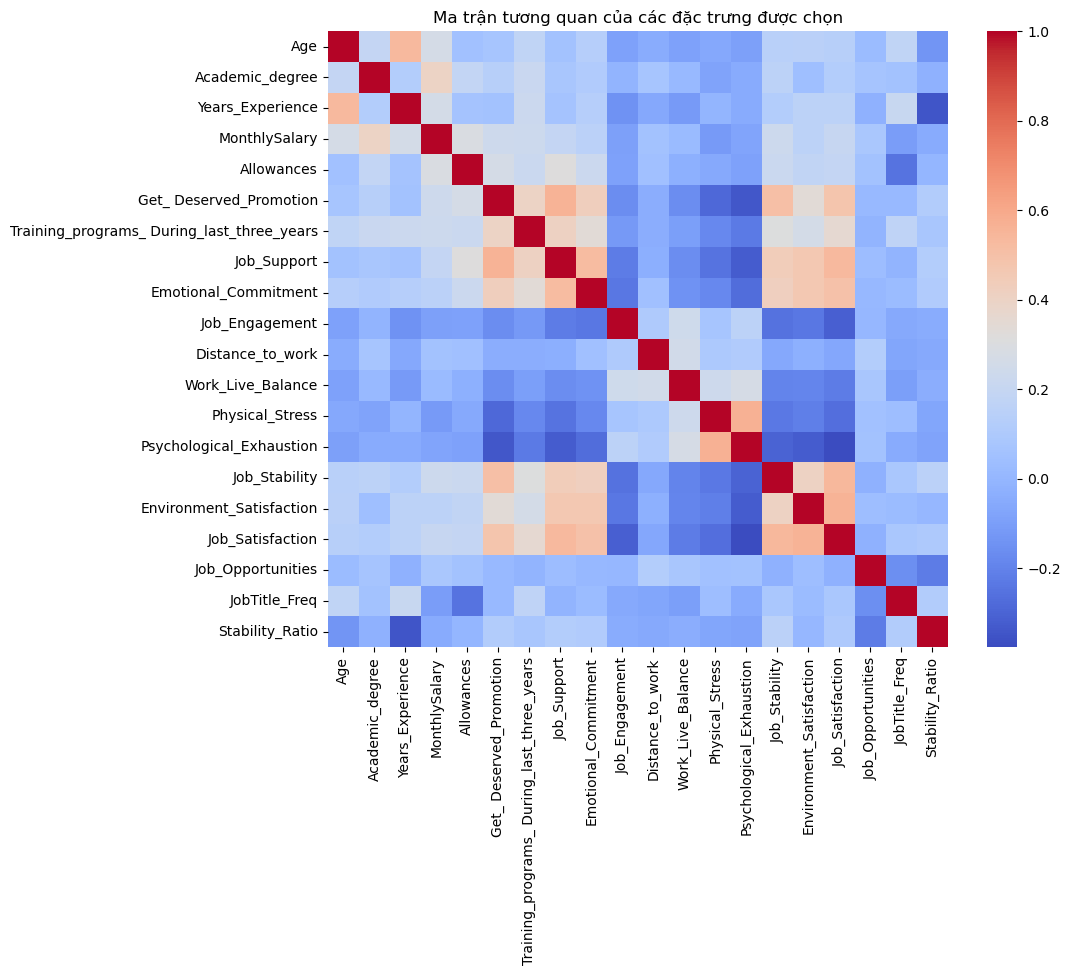

In [43]:
n_features = 20
rfe_selector = RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42), 
                   n_features_to_select=n_features, 
                   step=1)

rfe_selector.fit(X_train_filtered, y_train)

# Lấy danh sách các cột được chọn
selected_cols = X_train_filtered.columns[rfe_selector.support_]

print(f"Top {n_features} đặc trưng được chọn:")
print(list(selected_cols))

X_train_final = X_train_filtered[selected_cols]
X_test_final = X_test_filtered[selected_cols]

# Vẽ biểu đồ tương quan của các cột cuối cùng để kiểm tra lại
plt.figure(figsize=(10, 8))
sns.heatmap(X_train_final.corr(), cmap='coolwarm', annot=False)
plt.title('Ma trận tương quan của các đặc trưng được chọn')
plt.show()

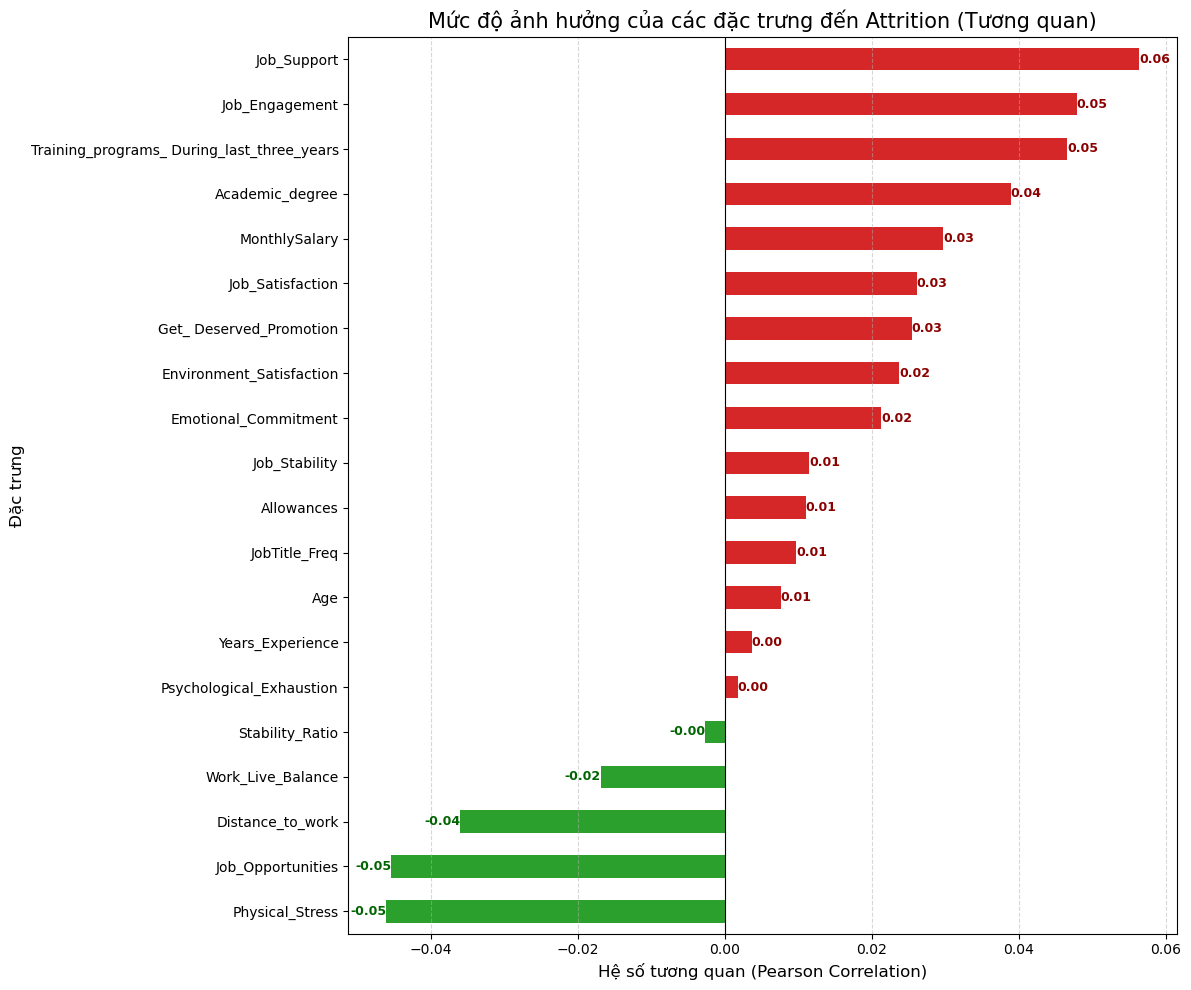

In [44]:
# --- BỔ SUNG: PHÂN TÍCH TƯƠNG QUAN VỚI BIẾN MỤC TIÊU (ATTRITION) ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính độ tương quan giữa các đặc trưng (X_train) và biến mục tiêu (y_train)
# Lưu ý: y_train phải ở dạng số (0/1) đã được xử lý ở các bước trước
# Sử dụng phương thức corrwith để tính tương quan từng cột X với y
correlations = X_train_final.corrwith(y_train)

# 2. Sắp xếp độ tương quan từ Dương (cao nhất) đến Âm (thấp nhất)
correlations = correlations.sort_values(ascending=True) # Sắp xếp tăng dần để vẽ barh cho đẹp

# ... (Phần tính toán correlations giữ nguyên) ...

# 3. Vẽ biểu đồ
plt.figure(figsize=(12, 10))

# [SỬA ĐỔI QUAN TRỌNG]: Đảo lại logic màu sắc
# - Tương quan DƯƠNG (> 0): Cùng chiều với Attrition (Làm tăng nghỉ việc) -> Màu ĐỎ (Cảnh báo)
# - Tương quan ÂM (< 0): Ngược chiều với Attrition (Giúp giữ chân) -> Màu XANH LÁ (Tốt)
colors = ['#2ca02c' if x < 0 else '#d62728' for x in correlations]

# Vẽ biểu đồ thanh ngang
correlations.plot(kind='barh', color=colors)

plt.title('Mức độ ảnh hưởng của các đặc trưng đến Attrition (Tương quan)', fontsize=15)
plt.xlabel('Hệ số tương quan (Pearson Correlation)', fontsize=12)
plt.ylabel('Đặc trưng', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Hiển thị giá trị lên biểu đồ
for index, value in enumerate(correlations):
    if value < 0:
        plt.text(value, index, f'{value:.2f}', va='center', ha='right', fontsize=9, fontweight='bold', color='darkgreen')
    else:
        plt.text(value, index, f'{value:.2f}', va='center', ha='left', fontsize=9, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

### <a id='3.6'>3.6. Kiểm định K-Fold</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

In [45]:
# Cấu hình mô hình và K-Fold
# Sử dụng RandomForest với cùng cấu hình như bước trước
model_kfold = RandomForestClassifier(n_estimators=100, random_state=42)

# StratifiedKFold: Đảm bảo tỷ lệ nghỉ việc (Attrition=Yes/No) cân bằng trong mỗi fold
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print(f"Đang thực hiện 10-Fold Cross-Validation trên tập dữ liệu...")

# Thực hiện kiểm định
# scoring='accuracy': Đánh giá bằng độ chính xác
cv_scores = cross_val_score(model_kfold, X_train_final, y_train, cv=kf, scoring='accuracy')

# In kết quả thống kê
print("\n" + "="*40)
print("KẾT QUẢ KIỂM ĐỊNH K-FOLD")
print("="*40)
print(f"Điểm số từng lần chạy (Folds): \n{cv_scores}")
print("-" * 40)
print(f"Độ chính xác trung bình (Mean Accuracy): {np.mean(cv_scores):.4f}")
print(f"Độ lệch chuẩn (Standard Deviation):      {np.std(cv_scores):.4f}")
print("="*40)


Đang thực hiện 10-Fold Cross-Validation trên tập dữ liệu...

KẾT QUẢ KIỂM ĐỊNH K-FOLD
Điểm số từng lần chạy (Folds): 
[0.82291667 0.83333333 0.77894737 0.8        0.86315789 0.83157895
 0.76842105 0.82105263 0.85263158 0.76842105]
----------------------------------------
Độ chính xác trung bình (Mean Accuracy): 0.8140
Độ lệch chuẩn (Standard Deviation):      0.0321


## <a id='4.'>4. Đưa ra kết quả sau khi xử lí dữ liệu </a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

In [46]:
import joblib

# Xuất ra CSV (để dễ nhìn)
X_train_final.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
X_test_final.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
df.to_csv('Clean_Data_for_EDA.csv', index=False)
print("Đã xuất dữ liệu thành công! Sẵn sàng cho Modeling.")

Đã xuất dữ liệu thành công! Sẵn sàng cho Modeling.


In [47]:
# Lưu Scaler (đã fit trên X_train)
joblib.dump(scaler, 'scaler.pkl')

# Lưu danh sách cột chuẩn (để App tạo dummy variable cho đúng thứ tự)
model_columns = list(X_train_final.columns)
joblib.dump(model_columns, 'model_columns.pkl')

['model_columns.pkl']